# 🟡 Lesson 11 — Xarray

**Level: Intermediate** · Labelled N-dimensional arrays — climate cubes, model grids, time × lat × lon data that NumPy alone can't manage.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
print("xarray", xr.__version__)

xarray 2026.4.0


## 1. Build a data cube: monthly ground temperature over a region
Dimensions: `time × lat × lon` — the classic geoscience shape.

In [2]:
rng = np.random.default_rng(0)
time = pd.date_range("2020-01-01", periods=24, freq="MS")
lat = np.linspace(-18, -12, 13)
lon = np.linspace(-76, -70, 13)

seasonal = 8 * np.cos(2 * np.pi * (time.month.values[:, None, None] - 1) / 12)
base = 18 + 0.5 * (lat[None, :, None] + 15)          # cooler to the south
temp = base + seasonal + rng.normal(0, 1, (24, 13, 13))

ds = xr.Dataset(
    {"temp": (("time", "lat", "lon"), temp)},
    coords={"time": time, "lat": lat, "lon": lon},
    attrs={"title": "Synthetic surface temperature", "units": "degC"},
)
ds

<xarray.Dataset> Size: 33kB
Dimensions:  (time: 24, lat: 13, lon: 13)
Coordinates:
  * time     (time) datetime64[ns] 192B 2020-01-01 2020-02-01 ... 2021-12-01
  * lat      (lat) float64 104B -18.0 -17.5 -17.0 -16.5 ... -13.0 -12.5 -12.0
  * lon      (lon) float64 104B -76.0 -75.5 -75.0 -74.5 ... -71.0 -70.5 -70.0
Data variables:
    temp     (time, lat, lon) float64 32kB 24.63 24.37 25.14 ... 27.21 26.12
Attributes:
    title:    Synthetic surface temperature
    units:    degC

## 2. Label-based selection — no index arithmetic

In [3]:
point = ds["temp"].sel(lat=-16.4, lon=-71.5, method="nearest")   # Arequipa-ish
print("Jan 2020 : %.1f degC" % float(point.sel(time="2020-01")))
print("Jul 2020 : %.1f degC" % float(point.sel(time="2020-07")))
print("2020 mean: %.1f degC" % float(point.sel(time="2020").mean()))

Jan 2020 : 27.1 degC
Jul 2020 : 8.7 degC
2020 mean: 17.5 degC


## 3. Aggregation along named dimensions

In [4]:
print("map of time-mean -> shape", ds["temp"].mean("time").shape)
print("regional monthly series -> shape", ds["temp"].mean(["lat", "lon"]).shape)

warmest = ds["temp"].mean(["lat", "lon"]).idxmax("time")
print("warmest month:", str(warmest.values)[:10])

map of time-mean -> shape (13, 13)
regional monthly series -> shape (24,)
warmest month: 2020-01-01


## 4. GroupBy — seasonal climatology in one line

In [5]:
clim = ds["temp"].groupby("time.season").mean()
print(clim.sel(lat=-16, lon=-71, method="nearest").round(1).to_series())

season
DJF    25.0
JJA     9.6
MAM    17.0
SON    18.0
Name: temp, dtype: float64


## 5. Plotting is built in

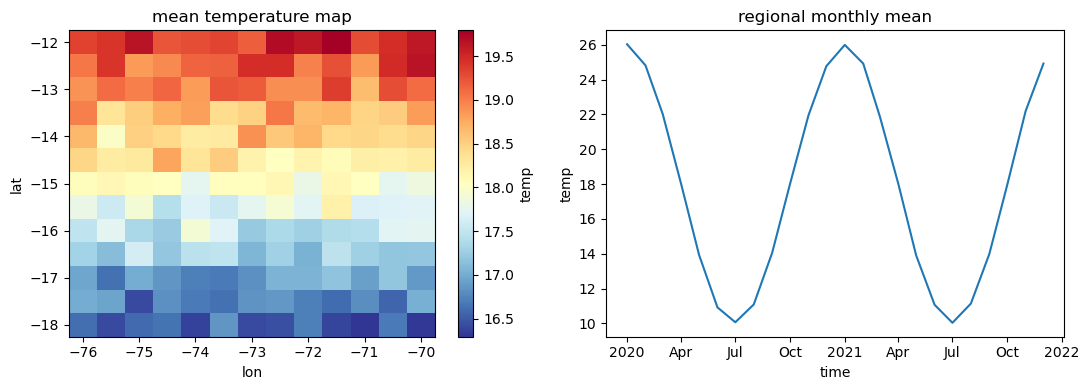

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ds["temp"].mean("time").plot(ax=axes[0], cmap="RdYlBu_r")
axes[0].set_title("mean temperature map")
ds["temp"].mean(["lat", "lon"]).plot(ax=axes[1])
axes[1].set_title("regional monthly mean")
plt.tight_layout(); plt.show()

## 6. Save / load NetCDF — the standard exchange format

In [7]:
from pathlib import Path
GEN = Path("..") / "data" / "generated"; GEN.mkdir(parents=True, exist_ok=True)
nc = GEN / "temperature_cube.nc"
ds.to_netcdf(nc)
back = xr.open_dataset(nc)
print("round-trip OK:", bool((back["temp"] == ds["temp"]).all()))
back.close()

round-trip OK: True


### ✏️ Try it
1. Compute the anomaly `ds['temp'] - ds['temp'].mean('time')` and plot the map for July 2021.
2. Resample the cube to quarterly means with `ds.resample(time='QS').mean()`.

📚 Docs: https://docs.xarray.dev/